# **WINE QUALITY PREDICTION**

In [1]:
import pandas as pd

# Load and Inspect the Dataset

In [2]:
df = pd.read_csv('winequality-red.csv')

In [3]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [4]:
df.shape

(1599, 12)

In [5]:
df.dtypes

fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object

In [6]:
df.describe

<bound method NDFrame.describe of       fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0               7.4             0.700         0.00             1.9      0.076   
1               7.8             0.880         0.00             2.6      0.098   
2               7.8             0.760         0.04             2.3      0.092   
3              11.2             0.280         0.56             1.9      0.075   
4               7.4             0.700         0.00             1.9      0.076   
...             ...               ...          ...             ...        ...   
1594            6.2             0.600         0.08             2.0      0.090   
1595            5.9             0.550         0.10             2.2      0.062   
1596            6.3             0.510         0.13             2.3      0.076   
1597            5.9             0.645         0.12             2.0      0.075   
1598            6.0             0.310         0.47             3.6      0.0

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [8]:
## Check Null Values

df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [9]:
# Check number of Duplicate rows

print('Duplicate rows:', df.duplicated().sum())

Duplicate rows: 240


In [10]:
## Check Quality Distribution

quality_counts = df['quality'].value_counts().sort_index()

print(quality_counts)

quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64


In [11]:
# Remove Duplicate rows 

df = df.drop_duplicates()
print('Dataset shape after removing duplicates:', df.shape)

Dataset shape after removing duplicates: (1359, 12)


In [12]:
# Check quality distribution after removing duplicates

df['quality'].value_counts().sort_index()

quality
3     10
4     53
5    577
6    535
7    167
8     17
Name: count, dtype: int64

In [13]:
# Check Percentage Distribution Of Wine Quality

quality_percentage = df['quality'].value_counts(normalize = True).sort_index() * 100
print(quality_percentage)

quality
3     0.735835
4     3.899926
5    42.457689
6    39.367182
7    12.288447
8     1.250920
Name: proportion, dtype: float64


# Distribution of Wine Quality Score

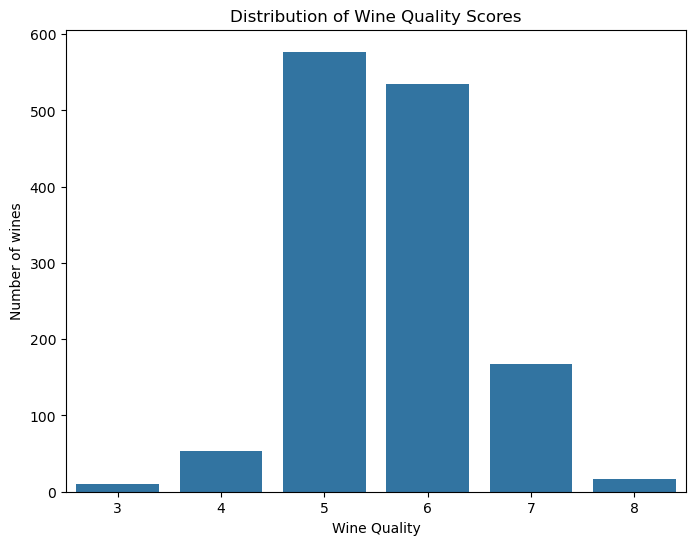

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns 

## Distribution of Wine Quality Scores

plt.figure(figsize = (8, 6))
sns.countplot(data = df, x = 'quality')
plt.title('Distribution of Wine Quality Scores')
plt.xlabel('Wine Quality')
plt.ylabel('Number of wines')
plt.show()

## Distribution of Wine Quality Scores(output)
The bar chart below shows the frequency of wines across different quality scores (3–8):
- **Most wines** fall in the **average range (5 and 6)**, with around 580 and 540 samples respectively.  
- **High quality wines (7–8)** are relatively fewer, with ~160 wines rated 7 and only ~10 wines rated 8.  
- **Low quality wines (3–4)** are rare, with ~10 wines rated 3 and ~60 wines rated 4.  
- This indicates a **class imbalance** in the dataset: the majority of wines are of medium quality, while extreme scores (very low or very high) are underrepresented.  
- Such imbalance can bias models toward predicting the majority classes (5 and 6),
- To address this issue, the quality scores will be grouped into two practical categories: Bad (3–5) and Good (6–8).

# Exploratory Data Analysis

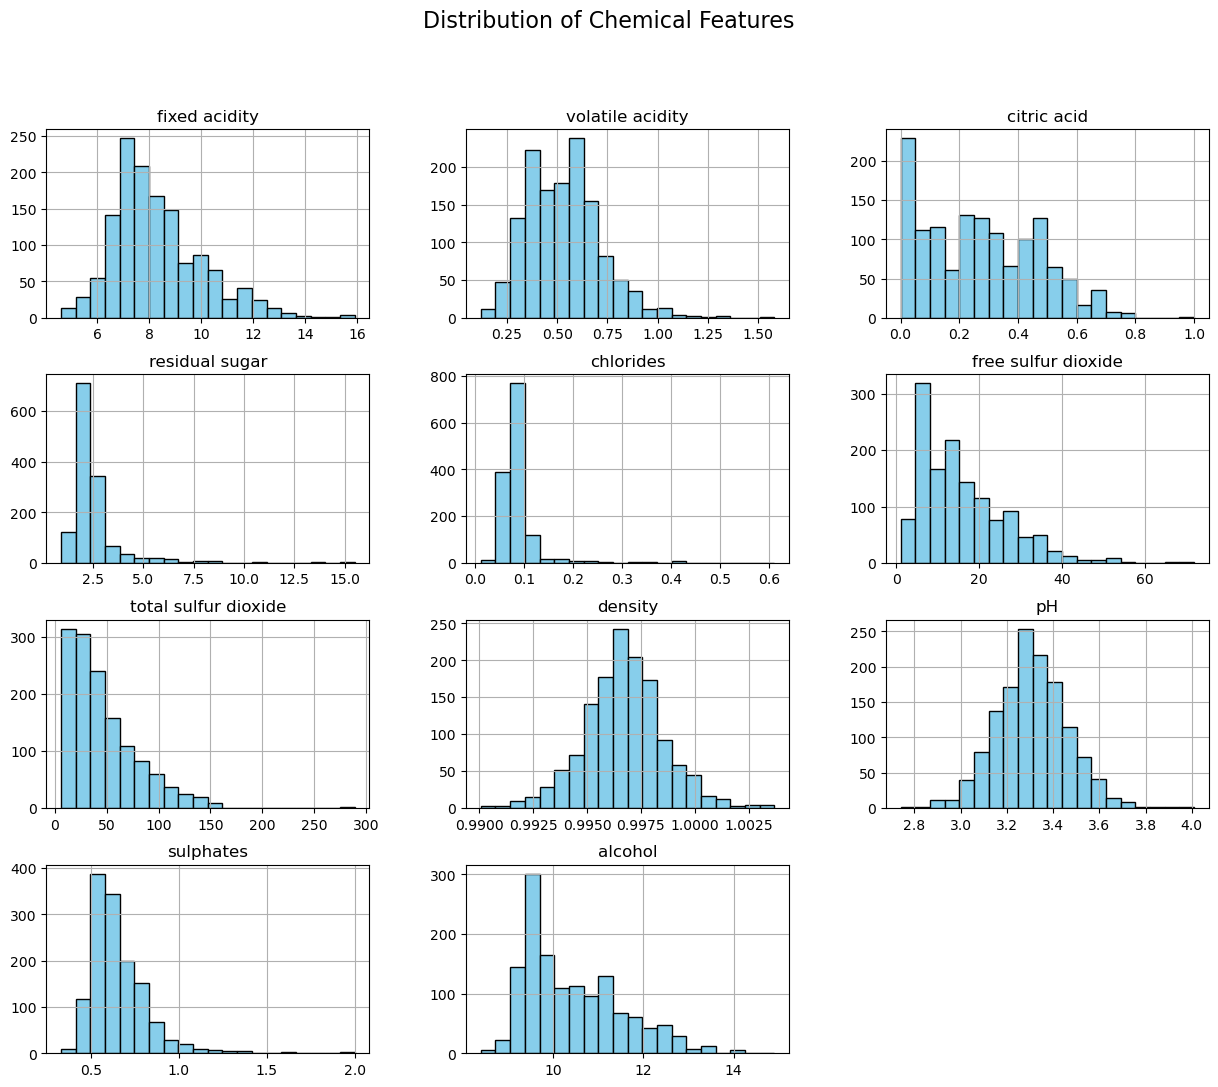

In [15]:
## Select only chemical features (exclude 'quality' column)
chemical_feature = df.drop(columns = ['quality'])

## Distribution plots for all chemical features
chemical_feature.hist(bins=20, figsize=(15,12), color='skyblue',edgecolor='black')
plt.suptitle("Distribution of Chemical Features", fontsize=16)
plt.show()

# Correlation HeatMap

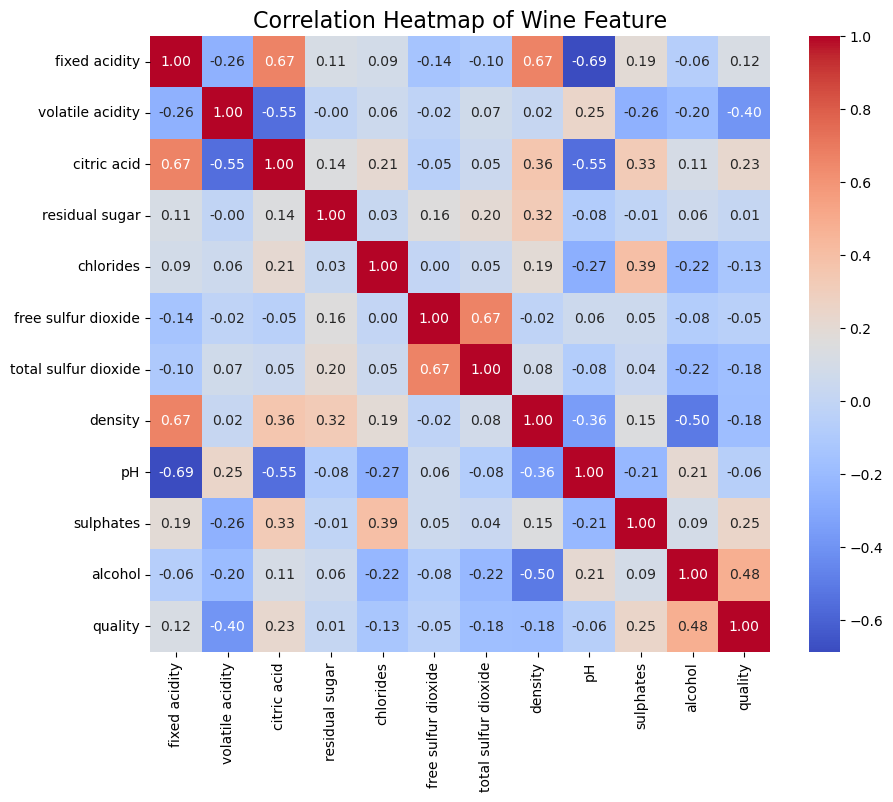

In [16]:
## Correlation Heatmap

plt.figure(figsize = (10, 8))
sns.heatmap(df.corr(), annot = True, cmap = 'coolwarm', fmt = '.2f')
plt.title('Correlation Heatmap of Wine Feature', fontsize = 16)
plt.show()

## Exploratory Data Analysis (EDA)
### Distribution Analysis of Chemical Features
The distribution plots show the following patterns:
- **Fixed acidity:** Mostly concentrated between 6–9, with slight right skewness.
- **Volatile acidity:** Mainly distributed between 0.3–0.7, with some higher values.
- **Citric acid:** Many observations are close to 0, with values spread up to 1.0.
- **Residual sugar:** Highly right-skewed, with most values below 4.
- **Chlorides:** Mostly concentrated around 0.05–0.10, with a few higher values.
- **Free sulfur dioxide:** Mostly concentrated at lower values with a right-skewed distribution.
- **Total sulfur dioxide:** Strongly right-skewed, with most observations below 100.
- **Density:** Relatively concentrated and approximately bell-shaped around 1.0.
- **pH:** Approximately normally distributed, mainly concentrated around 3.2–3.4.
- **Sulphates:** Mostly concentrated between 0.4–0.8, with slight right skewness.
- **Alcohol:** Mostly concentrated between 9–12%, with some higher values.
### Correlation Heatmap
- The heatmap shows the correlation between physicochemical features and wine quality.
- Alcohol has the strongest positive correlation with quality (0.48), while volatile acidity has the strongest negative correlation (-0.40).
- Sulphates (0.25) and citric acid (0.23) also show positive correlations with quality.
### Insight
- Overall, alcohol and volatile acidity have the most noticeable linear relationships with wine quality.
- Most chemical features are skewed, indicating the need for scaling/normalization in modelling.
- Correlation analysis helps identify which features are most influential for prediction.

# Class Imbalance
After removing 240 duplicate rows, the dataset has 1359 unique samples.  
The distribution of wine quality scores is:
- Quality **3** → 10 wines  
- Quality **4** → 53 wines  
- Quality **5** → 577 wines  
- Quality **6** → 535 wines  
- Quality **7** → 167 wines  
- Quality **8** → 17 wines  
### Observations
- **Majority classes**: 5 and 6 dominate the dataset (over 80% combined).  
- **Minority classes**: 3, 4, and 8 are severely underrepresented. 
### Impact on Modelling
- This imbalance can cause the models to favor the majority classes and reduce their ability to correctly identify minority-quality wines.
- Therefore, the quality scores will be grouped into **Bad (3–5)** and **Good (6–8)** to create a more balanced classification problem.
### Insight
- The dataset is dominated by average‑quality wines (scores 5–6).  
- Extreme quality scores (very low or very high) are rare, so grouping or resampling is necessary for fair and reliable modelling.

# Feature Engineering

In [17]:
## Convert quality scores into binary classes 

df['quality_label'] = df['quality'].apply(lambda x: 'Bad' if x <= 5 else 'Good')
df[['quality', 'quality_label']].head()

C:\Users\srish\AppData\Local\Temp\ipykernel_2200\751176157.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['quality_label'] = df['quality'].apply(lambda x: 'Bad' if x <= 5 else 'Good')


,quality,quality_label
0,5,Bad
1,5,Bad
2,5,Bad
3,6,Good
5,5,Bad


In [18]:
df['quality_label'].value_counts()

quality_label
Good    719
Bad     640
Name: count, dtype: int64

### Feature Engineering: Quality Binning

The original quality scores were grouped into two categories:

- **Bad:** Quality scores 3–5
- **Good:** Quality scores 6–8

- Binary classification was selected because it separates lower-quality wines from higher-quality wines and provides a more balanced distribution, with **47.1% Bad** and **52.9% Good** observations.
- It also makes the prediction task simpler and easier to interpret compared with predicting individual quality scores.

# Train/Test Split with Stratification

In [19]:
## Define feature and target 

X = df.drop(columns = ['quality', 'quality_label'])
y = df['quality_label']

In [20]:
## Train-Test Split with stratification

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 42, stratify = y)

print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)
print('y_train shape:', y_train.shape)
print('y_test shape:', y_train.shape)

X_train shape: (1087, 11)
X_test shape: (272, 11)
y_train shape: (1087,)
y_test shape: (1087,)


In [21]:
print("Training class distribution:")
print(y_train.value_counts(normalize=True).round(3))

print("\nTesting class distribution:")
print(y_test.value_counts(normalize=True).round(3))

Training class distribution:
quality_label
Good    0.529
Bad     0.471
Name: proportion, dtype: float64

Testing class distribution:
quality_label
Good    0.529
Bad     0.471
Name: proportion, dtype: float64


In [22]:
print("y_train distribution:\n", y_train.value_counts())
print("y_test distribution:\n", y_test.value_counts())

y_train distribution:
 quality_label
Good    575
Bad     512
Name: count, dtype: int64
y_test distribution:
 quality_label
Good    144
Bad     128
Name: count, dtype: int64


## Train-Test Split with Stratification

- The dataset was split into **80% training data (1,087 samples)** and **20% testing data (272 samples)**.
- Stratification was applied to preserve the class proportions in both sets.
- The **Good** class represents 52.9% and the **Bad** class represents 47.1% in both training and testing data, ensuring a fair model evaluation.

# Train 3 Classifiers (RF, SGD, SVC)

In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [24]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC

## Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators = 100 , random_state = 42)
rf_model.fit(X_train, y_train)

## Stochastic Gradient Descent (SGD)
sgd_model = SGDClassifier(random_state = 42)
sgd_model.fit(X_train_scaled, y_train)

## Support Vector Classifier (SVC)
svc_model = SVC(random_state = 42)
svc_model.fit(X_train_scaled, y_train)

print('All three models trained successfully')

All three models trained successfully


## Model Training

- Three classification models were successfully trained: **Random Forest, SGD Classifier, and Support Vector Classifier (SVC)**.
- Feature scaling was applied to the SGD and SVC models to ensure that differences in feature ranges do not negatively affect their performance.
- Using multiple classifiers allows comparison of performance. 

# Accuracy Score and Classification Report

In [25]:
## Acccuracy_Score and Classification_Report of RF,SGD,SVC

from sklearn.metrics import accuracy_score, classification_report

## Random Forest
rf_pred = rf_model.predict(X_test)
print('Random Forest Accuracy:', accuracy_score(y_test, rf_pred))
print('\nRandom Forest Classification Report:\n', classification_report(y_test, rf_pred))

## SGD
sgd_pred = sgd_model.predict(X_test_scaled)
print('Accuracy of SGD Classifier:', accuracy_score(y_test, sgd_pred))
print('\nClassification Report of SGD Classifier:\n', classification_report(y_test, sgd_pred))

## SVC
svc_pred = svc_model.predict(X_test_scaled)
print('Accuracy of SVC:', accuracy_score(y_test, svc_pred))
print('\nClassification Report of SVC:\n', classification_report(y_test, svc_pred))

Random Forest Accuracy: 0.75

Random Forest Classification Report:
               precision    recall  f1-score   support

         Bad       0.72      0.77      0.74       128
        Good       0.78      0.74      0.76       144

    accuracy                           0.75       272
   macro avg       0.75      0.75      0.75       272
weighted avg       0.75      0.75      0.75       272

Accuracy of SGD Classifier: 0.7242647058823529

Classification Report of SGD Classifier:
               precision    recall  f1-score   support

         Bad       0.70      0.73      0.71       128
        Good       0.75      0.72      0.73       144

    accuracy                           0.72       272
   macro avg       0.72      0.72      0.72       272
weighted avg       0.73      0.72      0.72       272

Accuracy of SVC: 0.7536764705882353

Classification Report of SVC:
               precision    recall  f1-score   support

         Bad       0.73      0.77      0.75       128
        Goo

## Model Evaluation
- **Random Forest:** Achieved an accuracy of **75.00%** with balanced precision and recall for both classes.
- **SGD Classifier:** Achieved an accuracy of **72.43%**, showing comparatively lower performance.
- **SVC:** Achieved the highest accuracy of **75.37%** with a balanced F1-score of **0.75**.

Overall, SVC performed slightly better than Random Forest, while SGD showed the lowest performance among the three models.

# Confusion Matrix

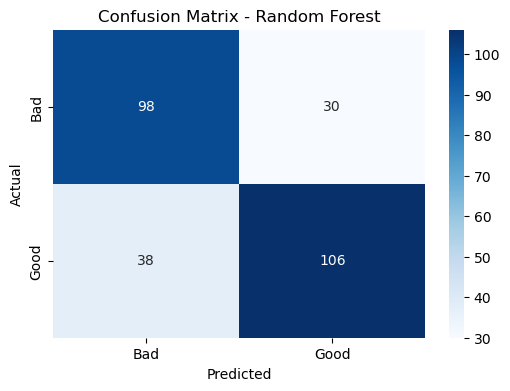

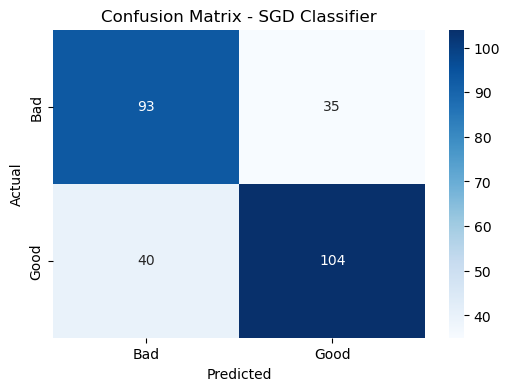

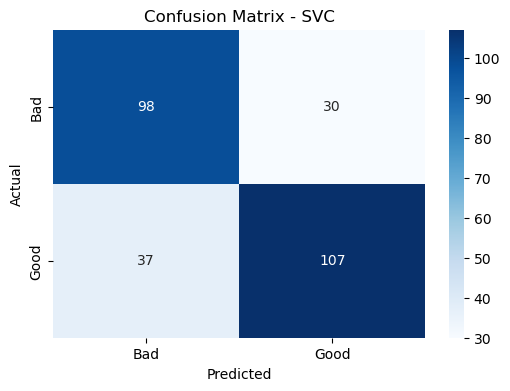

In [26]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

## Confusion Matrix
models = {
    "Random Forest": rf_pred,
    "SGD Classifier": sgd_pred,
    "SVC": svc_pred
}

for name, predictions in models.items():
    
    cm = confusion_matrix(y_test, predictions, labels=['Bad', 'Good'])
    
    plt.figure(figsize=(6, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['Bad', 'Good'],
        yticklabels=['Bad', 'Good']
    )
    
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

## Confusion Matrix Analysis
- **Random Forest:** Correctly classified 98 Bad and 106 Good wines, with 68 misclassifications.
- **SGD Classifier:** Correctly classified 93 Bad and 104 Good wines, with 75 misclassifications.
- **SVC:** Correctly classified 98 Bad and 107 Good wines, with 67 misclassifications.

SVC produced the highest number of correct predictions and the fewest misclassifications among the three models.

# Feature Importance Chart for Random Forest Model

In [27]:
## Random Forest Feature Importance 

feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(by = 'Importance', ascending = False)
print(feature_importance)

                 Feature  Importance
10               alcohol    0.213198
9              sulphates    0.121831
1       volatile acidity    0.108305
6   total sulfur dioxide    0.091078
7                density    0.082844
4              chlorides    0.071986
0          fixed acidity    0.068659
8                     pH    0.064993
2            citric acid    0.060122
5    free sulfur dioxide    0.059803
3         residual sugar    0.057181


## Random Forest Feature Importance
- **Alcohol** is the most important feature with an importance of 0.213.
- **Sulphates** (0.122) and volatile acidity (0.108) are also influential features.
- **Residual sugar** (0.057) has the lowest importance.
- Overall, **alcohol** contributes the most to distinguishing between Bad and Good wines.

C:\Users\srish\AppData\Local\Temp\ipykernel_2200\3573597626.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = feature_importance, x = 'Importance', y = 'Feature', palette = 'viridis')


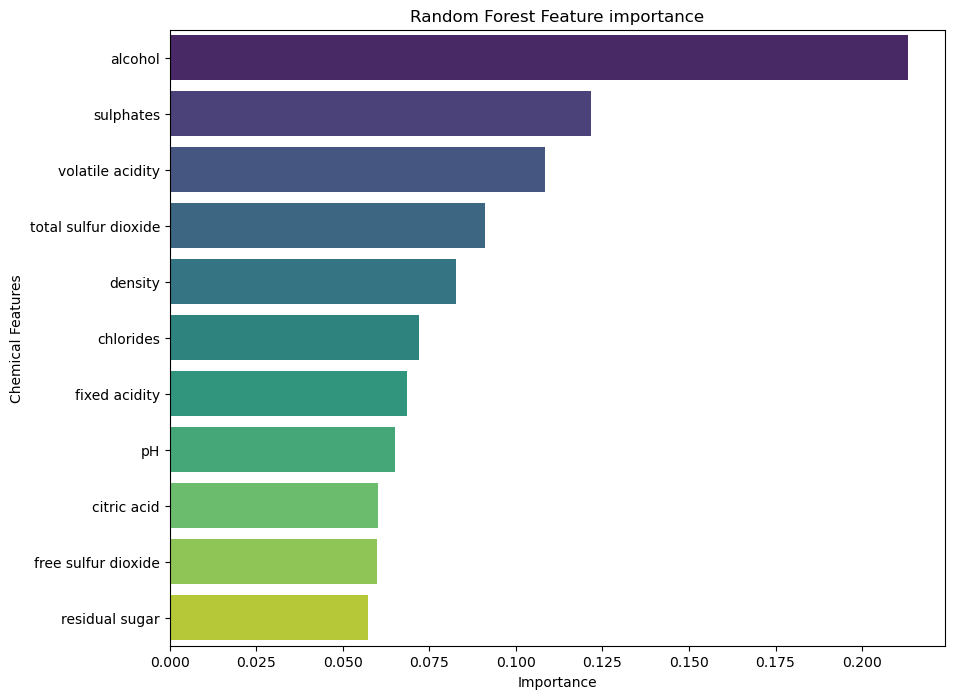

In [28]:
## Feature Importance Chart of Random Forest Model

plt.figure(figsize = (10, 8))
sns.barplot(data = feature_importance, x = 'Importance', y = 'Feature', palette = 'viridis')
plt.title('Random Forest Feature importance')
plt.xlabel('Importance')
plt.ylabel('Chemical Features')
plt.show()

## Feature Importance Interpretation
- The Random Forest model identifies **alcohol** as the most influential feature, followed by **sulphates** and **volatile acidity**.
- Features such as **residual sugar, free sulfur dioxide, and citric acid** have comparatively lower importance in the classification. 
- Overall, alcohol plays the largest role in distinguishing between Bad and Good wines.

# Comparison Table

In [31]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

## Comparison Table (Comparing RF, SGD, SVC)
comparison = pd.DataFrame({
    'Model': ['Random Forest', 'SGD Classifier', 'SVC'],

    'Accuracy': [
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, sgd_pred),
        accuracy_score(y_test, svc_pred)
    ],

    'Bad Precision': [
        precision_score(y_test, rf_pred, pos_label='Bad'),
        precision_score(y_test, sgd_pred, pos_label='Bad'),
        precision_score(y_test, svc_pred, pos_label='Bad')
    ],

    'Bad Recall': [
        recall_score(y_test, rf_pred, pos_label='Bad'),
        recall_score(y_test, sgd_pred, pos_label='Bad'),
        recall_score(y_test, svc_pred, pos_label='Bad')
    ],

    'Bad F1-Score': [
        f1_score(y_test, rf_pred, pos_label='Bad'),
        f1_score(y_test, sgd_pred, pos_label='Bad'),
        f1_score(y_test, svc_pred, pos_label='Bad')
    ],

    'Good Precision': [
        precision_score(y_test, rf_pred, pos_label='Good'),
        precision_score(y_test, sgd_pred, pos_label='Good'),
        precision_score(y_test, svc_pred, pos_label='Good')
    ],

    'Good Recall': [
        recall_score(y_test, rf_pred, pos_label='Good'),
        recall_score(y_test, sgd_pred, pos_label='Good'),
        recall_score(y_test, svc_pred, pos_label='Good')
    ],

    'Good F1-Score': [
        f1_score(y_test, rf_pred, pos_label='Good'),
        f1_score(y_test, sgd_pred, pos_label='Good'),
        f1_score(y_test, svc_pred, pos_label='Good')
    ]
})

comparison.round(3)

,Model,Accuracy,Bad Precision,Bad Recall,Bad F1-Score,Good Precision,Good Recall,Good F1-Score
0,Random Forest,0.750,0.721,0.766,0.742,0.779,0.736,0.757
1,SGD Classifier,0.724,0.699,0.727,0.713,0.748,0.722,0.735
2,SVC,0.754,0.726,0.766,0.745,0.781,0.743,0.762


## Model Comparison
The three classification models were compared using accuracy, precision, recall, and F1-score for both Bad and Good classes.
### Insight
- **RFC and SVC** achieved the highest accuracy (0.75) with balanced precision and recall.  
- **SGD** was slightly weaker (0.72) but remains useful for fast baseline modelling.  
- RFC offers interpretability (feature importance), while SVC provides strong decision boundaries.  

# Conclusion
- After comparing Random Forest, SGD Classifier, and SVC, **SVC is the most suitable model for deployment**.
- It achieved the highest accuracy of **75.37%** and the best F1-score for both **Bad (0.745)** and **Good (0.762)** wine classes.
- Its precision and recall are also well balanced, indicating consistent performance across both classes.
- Random Forest showed comparable performance, while SGD Classifier performed lower overall.
- Therefore, **SVC is selected as the final model** because it provides the strongest overall classification performance and effectively distinguishes between Bad and Good quality wines.